In [1]:
import numpy as np;
import pandas as pd;
import seaborn as sns;
import matplotlib.pyplot as plt;
from pandas import DataFrame,Series

In [2]:
df=pd.read_csv("/content/heart_data.csv")
df

,age,sex,BP,cholestrol,heart disease
0,70,1,130,322,1
1,67,0,115,564,0
2,57,1,124,261,1
3,64,1,128,263,0
4,74,0,120,269,0
...,...,...,...,...,...
265,52,1,172,199,0
266,44,1,120,263,0
267,56,0,140,294,0
268,57,1,140,192,0


In [3]:
df.isnull().sum()

,0
age,0
sex,0
BP,0
cholestrol,0
heart disease,0


<Axes: ylabel='cholestrol'>

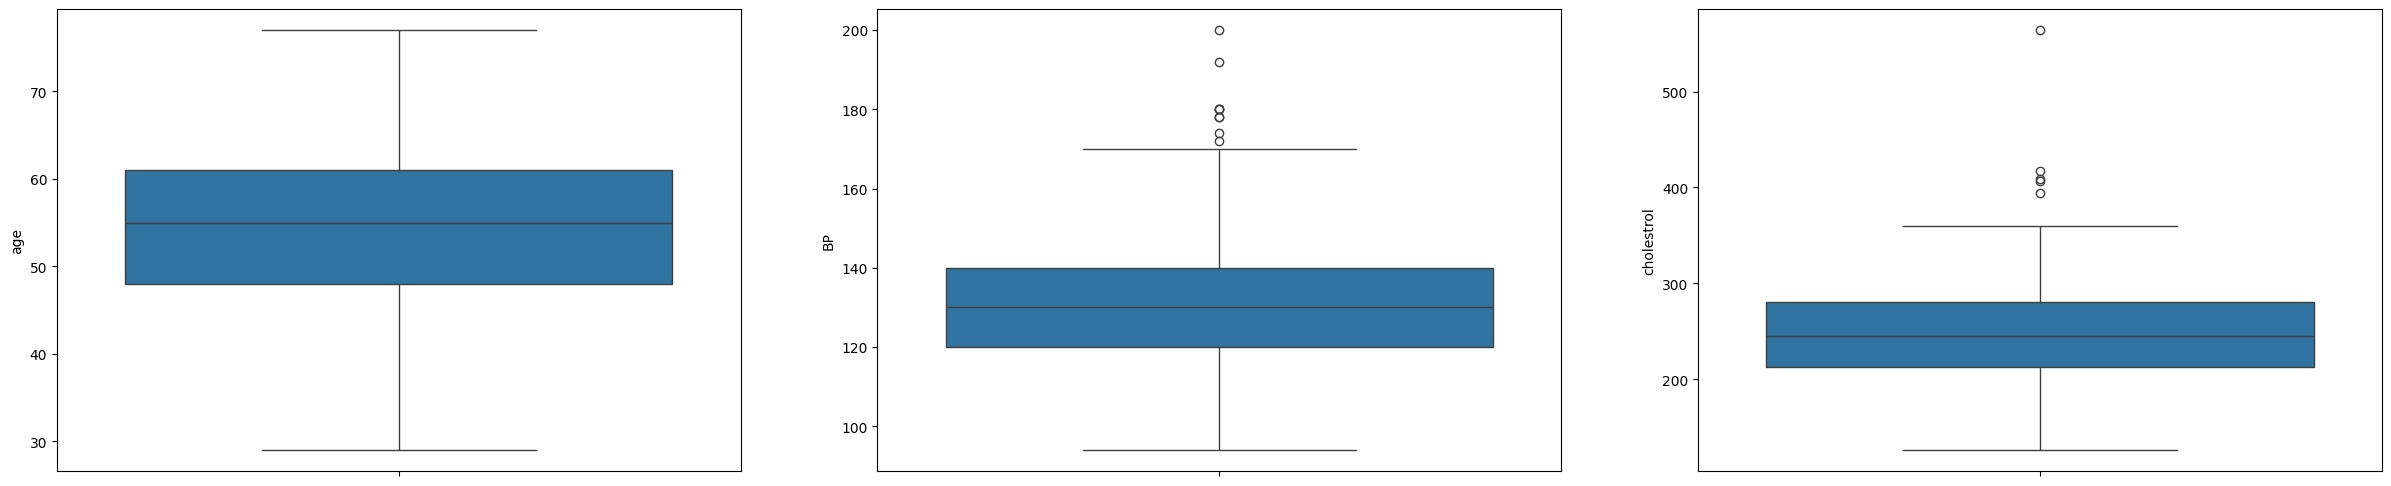

In [4]:
plt.figure( figsize = (30,6) )
plt.subplot(1,3,1);
sns.boxplot( df["age"] )

plt.subplot(1,3,2);
sns.boxplot( df["BP"] )

plt.subplot(1,3,3);
sns.boxplot( df["cholestrol"] )

# We have outliers in BP and Cholestrol

In [5]:
df.describe()

,age,sex,BP,cholestrol,heart disease
count,270.000000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,131.344444,249.659259,0.444444
std,9.109067,0.468195,17.861608,51.686237,0.497827
min,29.000000,0.000000,94.000000,126.000000,0.000000
25%,48.000000,0.000000,120.000000,213.000000,0.000000
50%,55.000000,1.000000,130.000000,245.000000,0.000000
75%,61.000000,1.000000,140.000000,280.000000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000


In [6]:
q1 = df.describe()["BP"]["25%"]
q1

np.float64(120.0)

In [7]:
q3 = df.describe()["BP"]["75%"]
q3

np.float64(140.0)

In [8]:
IQR=q3-q1
IQR

np.float64(20.0)

In [9]:
lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR
print( upper_limit,lower_limit )

170.0 90.0


Fixing outliers using capping technique

In [10]:
df["BP"]=df["BP"].clip(lower_limit,upper_limit )

In [11]:
q1 = df.describe()["cholestrol"]["25%"]
q1

np.float64(213.0)

In [12]:
q3 = df.describe()["cholestrol"]["75%"]
q3

np.float64(280.0)

In [13]:
IQR=q3-q1
IQR

np.float64(67.0)

In [14]:
lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR
print(lower_limit,upper_limit)

112.5 380.5


In [15]:
df["cholestrol"]=df["cholestrol"].clip(lower_limit,upper_limit )

<Axes: ylabel='cholestrol'>

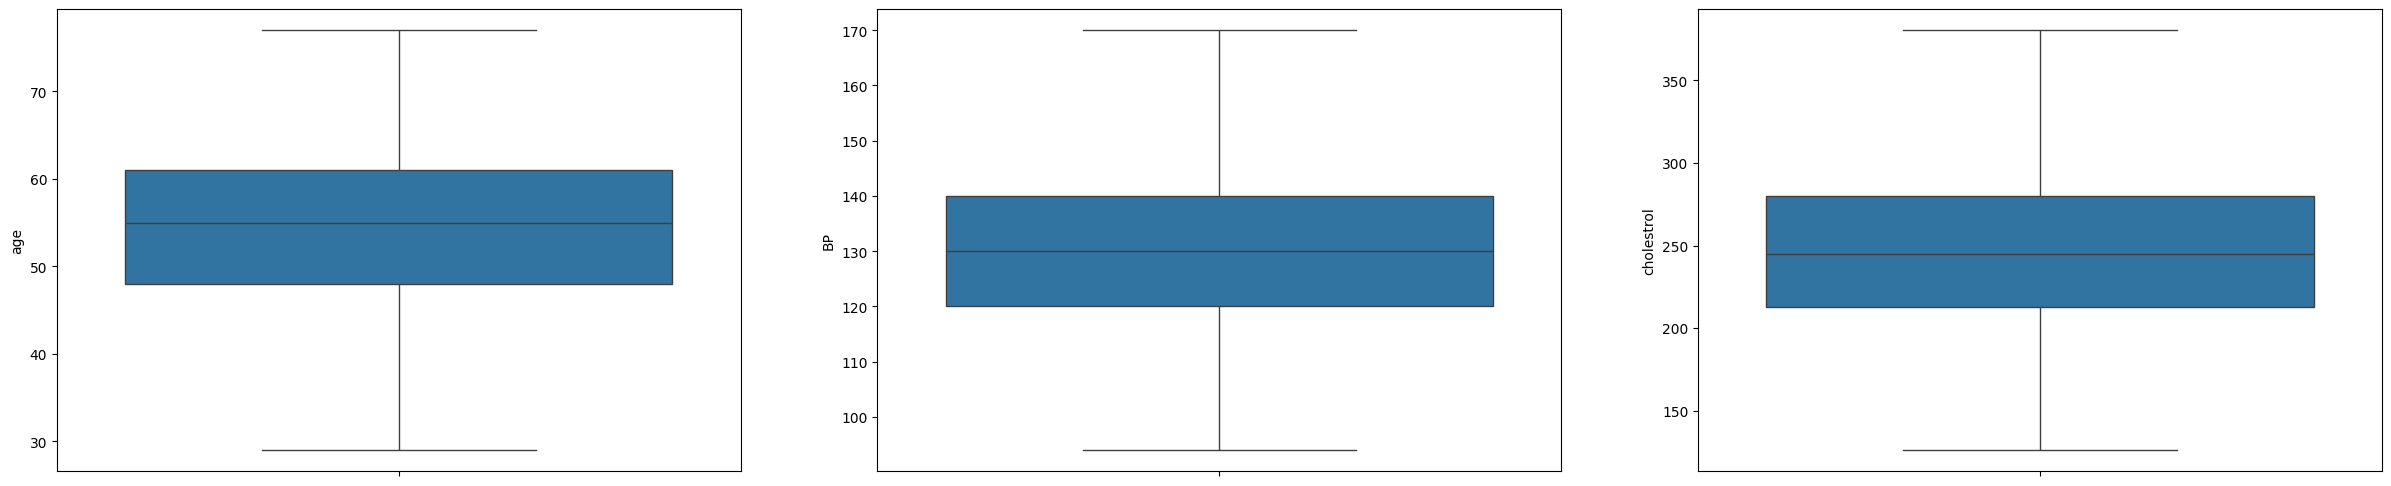

In [16]:
plt.figure( figsize = (30,6) )
plt.subplot(1,3,1);
sns.boxplot( df["age"] )

plt.subplot(1,3,2);
sns.boxplot( df["BP"] )

plt.subplot(1,3,3);
sns.boxplot( df["cholestrol"] )

In [17]:
X=df.drop(columns="heart disease");
X.head(5)

,age,sex,BP,cholestrol
0,70,1,130,322.0
1,67,0,115,380.5
2,57,1,124,261.0
3,64,1,128,263.0
4,74,0,120,269.0


In [18]:
Y=df["heart disease"]
Y.head(5)

,heart disease
0,1
1,0
2,1
3,0
4,0


In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=0)

In [20]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(216, 4) (54, 4) (216,) (54,)


use feature scale to get similar range for BP and cholestrol

In [21]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()

In [22]:
data=ss.fit_transform(x_train)
data

array([[ 1.21011243e+00,  6.70570227e-01, -6.83556752e-01,
        -1.48582217e+00],
       [-1.21521624e+00,  6.70570227e-01, -9.89373360e-01,
         1.17957915e+00],
       [ 4.38416945e-01, -1.49126812e+00, -1.90682318e+00,
         1.61103218e-02],
       [ 1.07690309e-01, -1.49126812e+00,  2.37460933e+00,
         1.68727464e+00],
       [-1.10497402e+00,  6.70570227e-01,  5.39709680e-01,
        -2.58891402e-01],
       [ 4.38416945e-01,  6.70570227e-01, -3.77740144e-01,
         1.11611721e+00],
       [ 6.58901370e-01, -1.49126812e+00,  1.15134290e+00,
        -1.53121508e-01],
       [-4.43520752e-01,  6.70570227e-01, -1.33086857e-01,
        -1.08389657e+00],
       [ 5.48659158e-01,  6.70570227e-01,  5.39709680e-01,
        -5.55047104e-01],
       [-1.43570066e+00,  6.70570227e-01, -1.29518997e+00,
        -2.58891402e-01],
       [ 2.42277676e+00, -1.49126812e+00,  5.39709680e-01,
        -1.06274259e+00],
       [ 5.48659158e-01,  6.70570227e-01, -3.16576822e-01,
      

In [23]:
x_trained_scaled=pd.DataFrame(data,columns=x_train.columns)

In [24]:
data=ss.fit_transform(x_test)
x_test_scaled=pd.DataFrame(data,columns=x_test.columns)

In [25]:
x_test_scaled.head(2)

,age,sex,BP,cholestrol
0,0.770278,0.766965,0.813837,-0.442804
1,-1.120405,-1.303840,0.650059,-1.623613


# Train the model

In [26]:
import pandas as pd;
from sklearn.linear_model import LogisticRegression

In [27]:
log = LogisticRegression()

In [28]:
log.fit(x_trained_scaled,y_train)

LogisticRegression()

In [29]:
y_pred=log.predict(x_test_scaled)
y_pred

array([1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0])

In [30]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [31]:
confusion_matrix(y_test,y_pred)

array([[21,  9],
       [10, 14]])

In [32]:
accuracy_score(y_test,y_pred)

0.6481481481481481

In [33]:
precision_score(y_test,y_pred)

0.6086956521739131

In [34]:
def heart_disease_predictor (age, sex, bp, cholestrol):
  result = log.predict([[age, sex, bp, cholestrol]])
  if result == 1:
    return "Heart Disease"
  else:
    return "No Heart Disease"

In [35]:
heart_disease_predictor(-0.6329,-1.524,0.151441,0.4760)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


'No Heart Disease'

In [36]:
x_trained_scaled

,age,sex,BP,cholestrol
0,1.210112,0.670570,-0.683557,-1.485822
1,-1.215216,0.670570,-0.989373,1.179579
2,0.438417,-1.491268,-1.906823,0.016110
3,0.107690,-1.491268,2.374609,1.687275
4,-1.104974,0.670570,0.539710,-0.258891
...,...,...,...,...
211,-1.104974,0.670570,-0.071924,-0.597355
212,-0.002552,0.670570,-1.417517,1.306503
213,0.217933,-1.491268,2.374609,0.862269
214,-1.104974,0.670570,-1.295190,-1.062743


**confusion matrix is used to evaluate the performance of a classification model by comparing actual values vs predicted values.**

For Binary Classification:

	Predicted 0	Predicted 1
Actual 0	TN = 2  	FP = 0

Actual 1	FN = 1	  TP = 2

Where:

TP (True Positive) → Correctly predicted positive

TN (True Negative) → Correctly predicted negative

FP (False Positive) → Predicted positive but actually negative

FN (False Negative) → Predicted negative but actually positive

F1 Score is a performance metric used for classification models. It combines Precision and Recall into a single score.

It is especially useful when:

Classes are imbalanced (for example: 95% No, 5% Yes)

You want a balance between false positives and false negatives

F1=2×Precision+Recall/
Precision×Recall​

1. Precision

Measures how many predicted positives are actually correct.

Precision=
TP+FP/
TP
	​

TP → True Positive
FP → False Positive

Example:
If model predicted 10 people as sick and only 8 are actually sick:

Precision=
10/
8
	​

=0.8

2. Recall (Sensitivity)

Measures how many actual positives the model identified correctly.

Recall=
TP+FN
TP
	​

TP → True Positive
FN → False Negative

Example:
If there are 12 sick people and model identified 8:

Recall=
12/
8
	​

=0.67

Calculate F1:

Using above values:

F1=2×
0.8+0.67/
0.8×0.67
	​

F1≈0.73
Interpretation:
F1 = 1 → Perfect model
F1 = 0 → Worst performance
Higher F1 → Better balance between precision and recall